# Targeted Attack + Clean-Basis SVD Vaccination by Score Tier (Taiwan Bankruptcy)

**Purpose:** Same experiment as targeted_vaccination_by_tier.ipynb, but the SVD basis is
precomputed from clean data

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import json
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DATA_DIR = Path('../../data/taiwan_bankruptcy_10_40_50')
SCORES_DIR = Path('../../outputs/noise_scoring/taiwan_bankruptcy_10_40_50/20260514_161236')
# PREV_RESULTS_DIR = Path('../../outputs/targeted_vaccination_50_50')
PREV_RESULTS_DIR = Path('../../outputs/taiwan_bankruptcy_targeted_vaccination_10_40_50')
# OUTPUT_DIR = Path('../../outputs/targeted_vaccination_clean_basis_50_50')
OUTPUT_DIR = Path('../../outputs/taiwan_bankruptcy_targeted_vaccination_clean_basis_10_40_50')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.1
MAXITERS = 300
LAMBDAS = {'aggressive': 0.1, 'stealthy': 50.0}
ATTACK_PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
K_RANKS = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 70, 94]

Device: cuda
GPU: NVIDIA RTX A6000


## 1. Load Data, Model, and Noise Scores

In [3]:
data = np.load(DATA_DIR / 'train_test_data.npz')
X_train = data['X_train'].astype(np.float32)  # 2727-sample MLP train partition (not used for Vt)
n_svd_basis_rows = int(data['X_svd'].shape[0])
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test']
n_test, n_features = X_test.shape

prep = np.load(DATA_DIR / 'preprocessing.npz')
weights = prep['weights']
bounds = [prep['bounds_min'], prep['bounds_max']]


class BankruptcyNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)

checkpoint = torch.load(DATA_DIR / 'taiwan_bankruptcy_mlp.pth', map_location=device)
model = BankruptcyNet(checkpoint['D_in']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

X_test_t = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)

print(f'MLP train partition: {X_train.shape[0]} samples, {n_features} features')
print(f'SVD basis partition: {n_svd_basis_rows} samples (see clean_svd_basis.npz)')
print(f'Test set: {n_test} samples, {n_features} features')
print(f'Correctly classified: {n_correct}/{n_test} ({n_correct/n_test:.2%})')

MLP train partition: 2727 samples, 94 features
SVD basis partition: 682 samples (see clean_svd_basis.npz)
Test set: 3410 samples, 94 features
Correctly classified: 2998/3410 (87.92%)


In [4]:
score1_removal_order = np.load(SCORES_DIR / 'test_clean_data_score1_removed_index.npy').astype(int)
score2_value = np.load(SCORES_DIR / 'test_clean_data_score2_noise_scores.npy')

score1_order = [idx for idx in score1_removal_order if correct_mask[idx]]
score2_order = [idx for idx in np.argsort(score2_value)[::-1] if correct_mask[idx]]

score_orders = {'Score 1': score1_order, 'Score 2': score2_order}
print(f'Eligible points per score ordering: {len(score1_order)}')

Eligible points per score ordering: 2998


## 2. Load Clean-Basis SVD (10% holdout partition)


`Vt_clean` from `clean_svd_basis.npz` (SVD on the 10% holdout partition, 682 rows), saved by `taiwan_bankruptcy_setup.ipynb`._

In [5]:
svd_basis = np.load(DATA_DIR / 'clean_svd_basis.npz')
Vt_clean = svd_basis['Vt_svd'].astype(np.float32)
S_clean = svd_basis['S_svd']
print(f'Clean basis shape: Vt_clean = {Vt_clean.shape} (SVD rows = {n_svd_basis_rows})')
print(f'Top-10 singular values: {S_clean[:10].round(2)}')
print(f'Cumulative energy at each k:')
cumvar = np.cumsum(S_clean**2) / np.sum(S_clean**2)
for k in K_RANKS:
    print(f'  k={k:>2d}: {cumvar[k-1]:.4f}')

Clean basis shape: Vt_clean = (94, 94) (SVD rows = 682)
Top-10 singular values: [110.43  10.73   9.91   9.14   7.59   7.3    7.23   6.3    6.12   5.8 ]
Cumulative energy at each k:
  k= 1: 0.9477
  k= 2: 0.9566
  k= 3: 0.9642
  k= 5: 0.9752
  k=10: 0.9920
  k=15: 0.9973
  k=20: 0.9989
  k=30: 0.9998
  k=40: 1.0000
  k=50: 1.0000
  k=70: 1.0000
  k=94: 1.0000


## 3. Load Adversarial Samples

In [6]:
adv_file = PREV_RESULTS_DIR / 'adversarial_samples.npz'
assert adv_file.exists(), f'Run targeted_vaccination_by_tier.ipynb first to generate {adv_file}'

adv_data = np.load(adv_file)
X_adv = {
    'aggressive': adv_data['X_adv_aggressive'],
    'stealthy':   adv_data['X_adv_stealthy'],
}
attack_success = {
    'aggressive': adv_data['success_aggressive'],
    'stealthy':   adv_data['success_stealthy'],
}

for regime in LAMBDAS:
    n_succ = attack_success[regime][correct_indices].sum()
    print(f'{regime}: {n_succ}/{n_correct} ({n_succ/n_correct:.2%}) attacks succeeded')

aggressive: 2998/2998 (100.00%) attacks succeeded
stealthy: 2926/2998 (97.60%) attacks succeeded


## 4. Clean-Basis Vaccination Sweep

In [7]:
rows = []
t_total = time.time()

for score_name, order in score_orders.items():
    n_eligible = len(order)
    for attack_pct in ATTACK_PCTS:
        n_attack = max(1, int(n_eligible * attack_pct / 100))

        noisy_indices = order[:n_attack]
        structural_indices = order[-n_attack:]

        for tier_name, tier_idx in [('structural', structural_indices), ('noisy', noisy_indices)]:
            tier_set = set(tier_idx)
            for regime in LAMBDAS:
                X_mixed = np.copy(X_test)
                n_successfully_attacked = 0
                for idx in tier_idx:
                    if attack_success[regime][idx]:
                        X_mixed[idx] = X_adv[regime][idx]
                        n_successfully_attacked += 1

                if n_successfully_attacked == 0:
                    for k in K_RANKS:
                        rows.append({
                            'score_type': score_name, 'tier': tier_name, 'regime': regime,
                            'attack_pct': attack_pct, 'k': k,
                            'n_targeted': len(tier_idx), 'n_attacked': 0,
                            'restoration_rate': 0.0, 'asr_after': 0.0,
                        })
                    continue

                for k in K_RANKS:
                    # Project onto precomputed clean basis instead of computing SVD on X_mixed
                    Vk = Vt_clean[:k, :]  # (k, 94)
                    X_vacc = (X_mixed @ Vk.T) @ Vk  # project and reconstruct
                    X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)

                    with torch.no_grad():
                        preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()

                    n_restored = sum(
                        1 for idx in tier_idx
                        if attack_success[regime][idx] and preds[idx] == y_test[idx]
                    )
                    restoration_rate = n_restored / n_successfully_attacked

                    rows.append({
                        'score_type': score_name, 'tier': tier_name, 'regime': regime,
                        'attack_pct': attack_pct, 'k': k,
                        'n_targeted': len(tier_idx), 'n_attacked': n_successfully_attacked,
                        'restoration_rate': restoration_rate, 'asr_after': 1 - restoration_rate,
                    })

        print(f'{score_name} | attack_pct={attack_pct:>3d}% done ({time.time()-t_total:.1f}s)')

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / 'vaccination_sweep.csv', index=False)
print(f'\nSweep complete: {len(df)} rows, saved to {OUTPUT_DIR / "vaccination_sweep.csv"}')

Score 1 | attack_pct= 10% done (0.1s)
Score 1 | attack_pct= 20% done (0.2s)
Score 1 | attack_pct= 30% done (0.2s)


Score 1 | attack_pct= 40% done (0.3s)
Score 1 | attack_pct= 50% done (0.5s)
Score 1 | attack_pct= 60% done (0.6s)
Score 1 | attack_pct= 70% done (0.7s)
Score 1 | attack_pct= 80% done (0.8s)
Score 1 | attack_pct= 90% done (0.9s)
Score 1 | attack_pct=100% done (1.1s)
Score 2 | attack_pct= 10% done (1.1s)
Score 2 | attack_pct= 20% done (1.2s)
Score 2 | attack_pct= 30% done (1.3s)
Score 2 | attack_pct= 40% done (1.5s)
Score 2 | attack_pct= 50% done (1.6s)
Score 2 | attack_pct= 60% done (1.7s)
Score 2 | attack_pct= 70% done (1.8s)
Score 2 | attack_pct= 80% done (2.0s)
Score 2 | attack_pct= 90% done (2.1s)
Score 2 | attack_pct=100% done (2.3s)

Sweep complete: 960 rows, saved to ../../outputs/taiwan_bankruptcy_targeted_vaccination_clean_basis_10_40_50/vaccination_sweep.csv


## 5. Heatmaps

Saved vaccination_clean_score1_structural.png


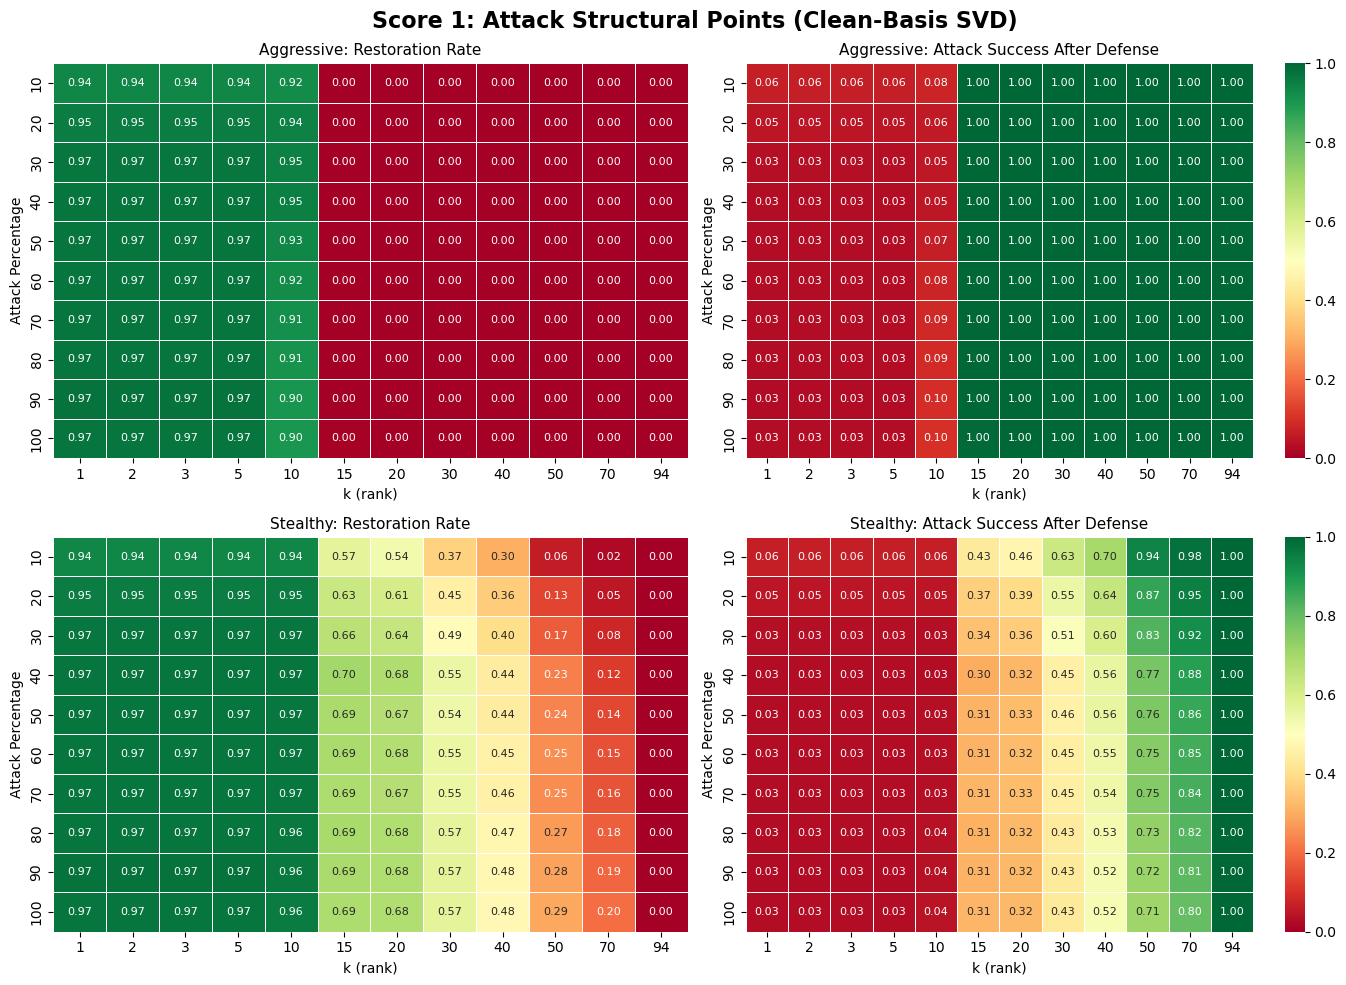

Saved vaccination_clean_score1_noisy.png


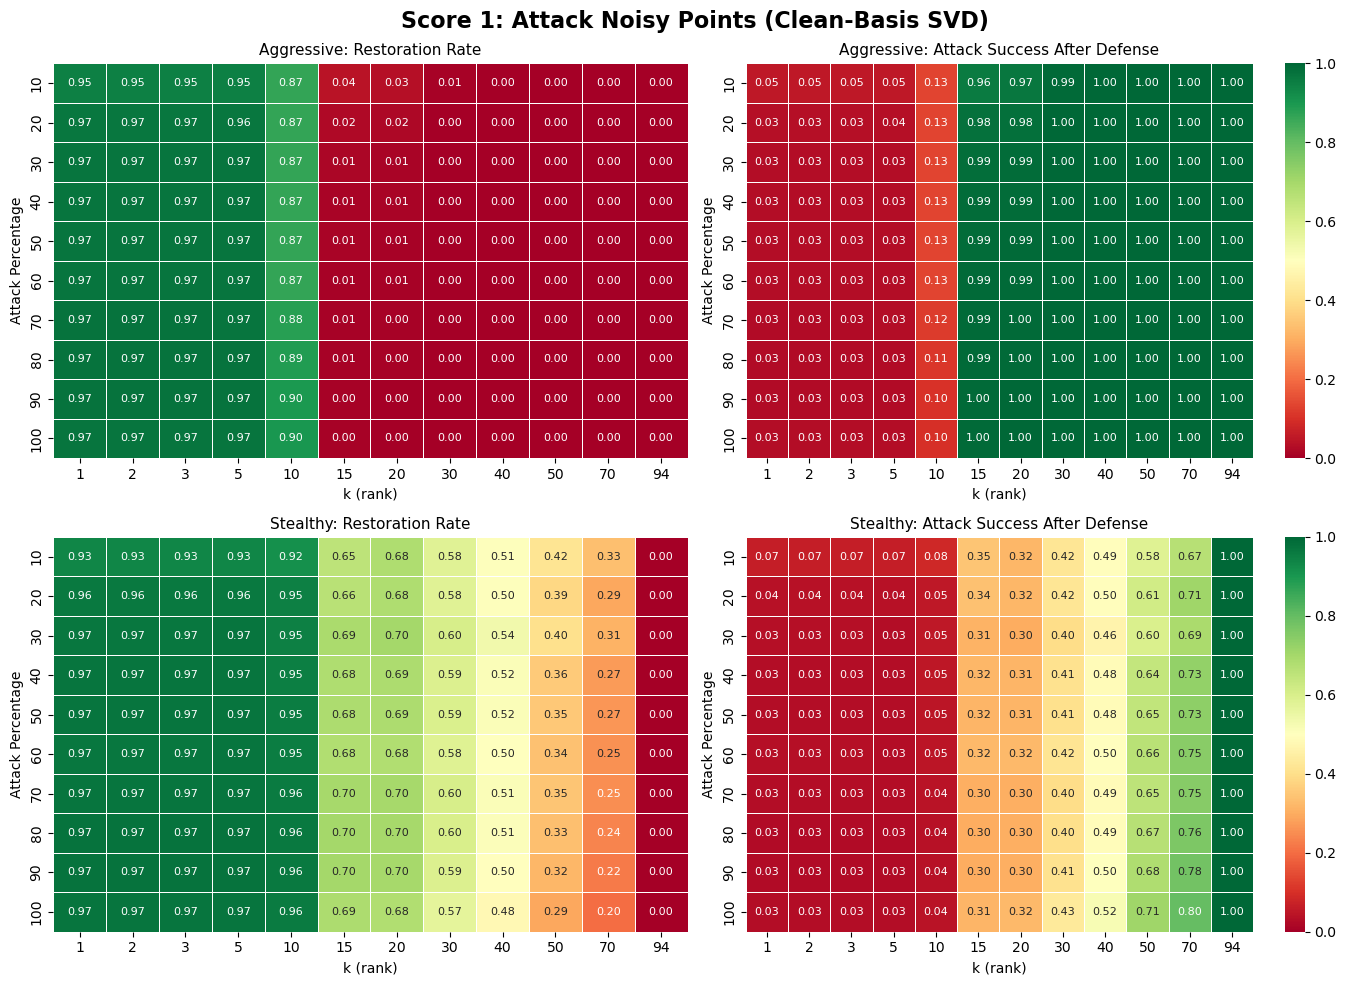

Saved vaccination_clean_score2_structural.png


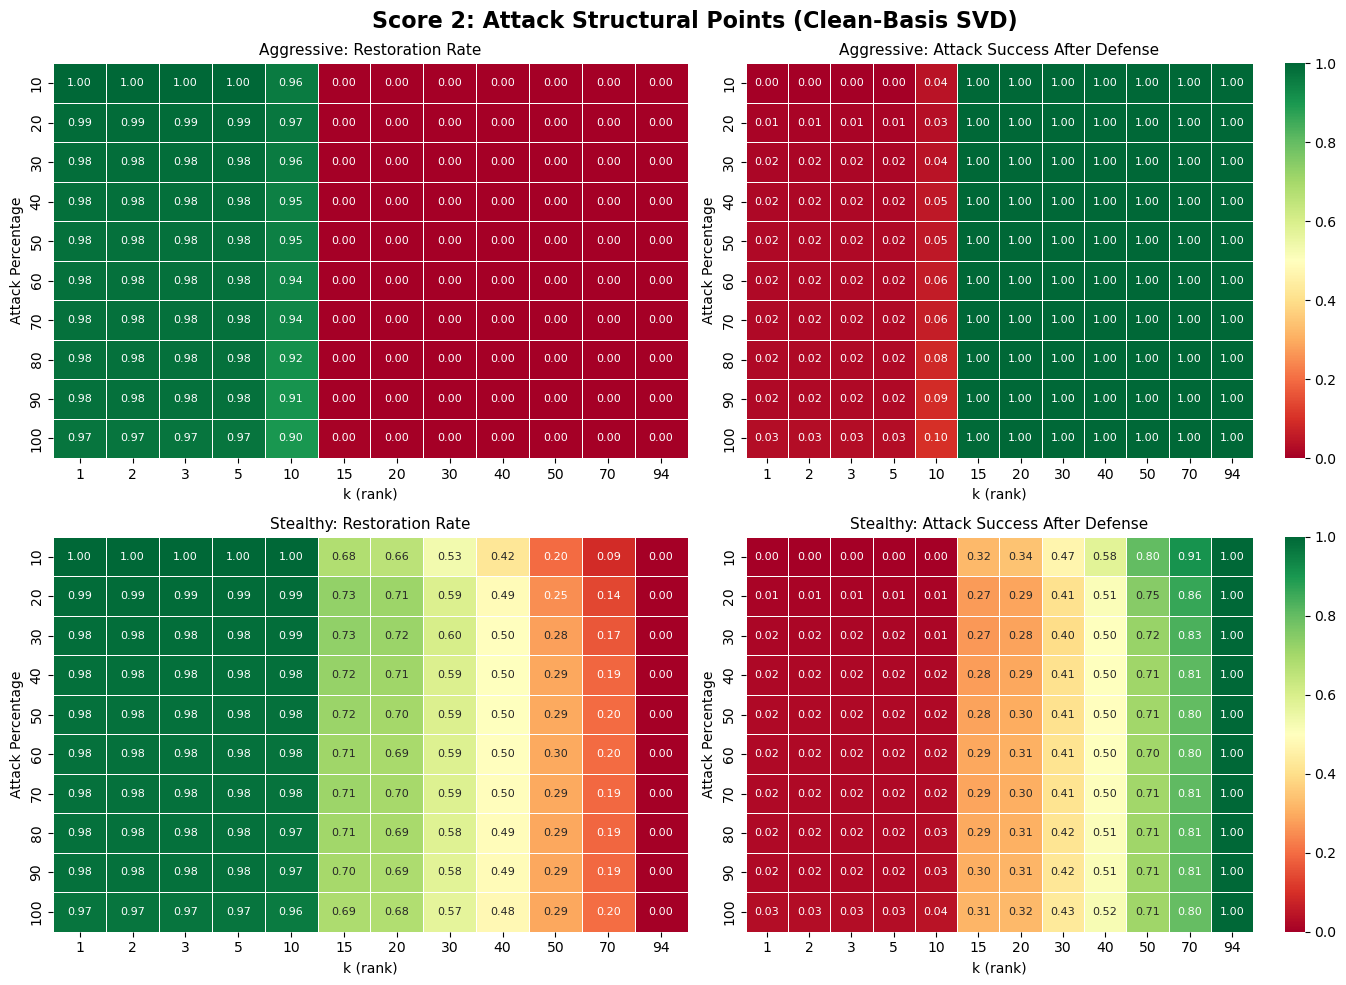

Saved vaccination_clean_score2_noisy.png


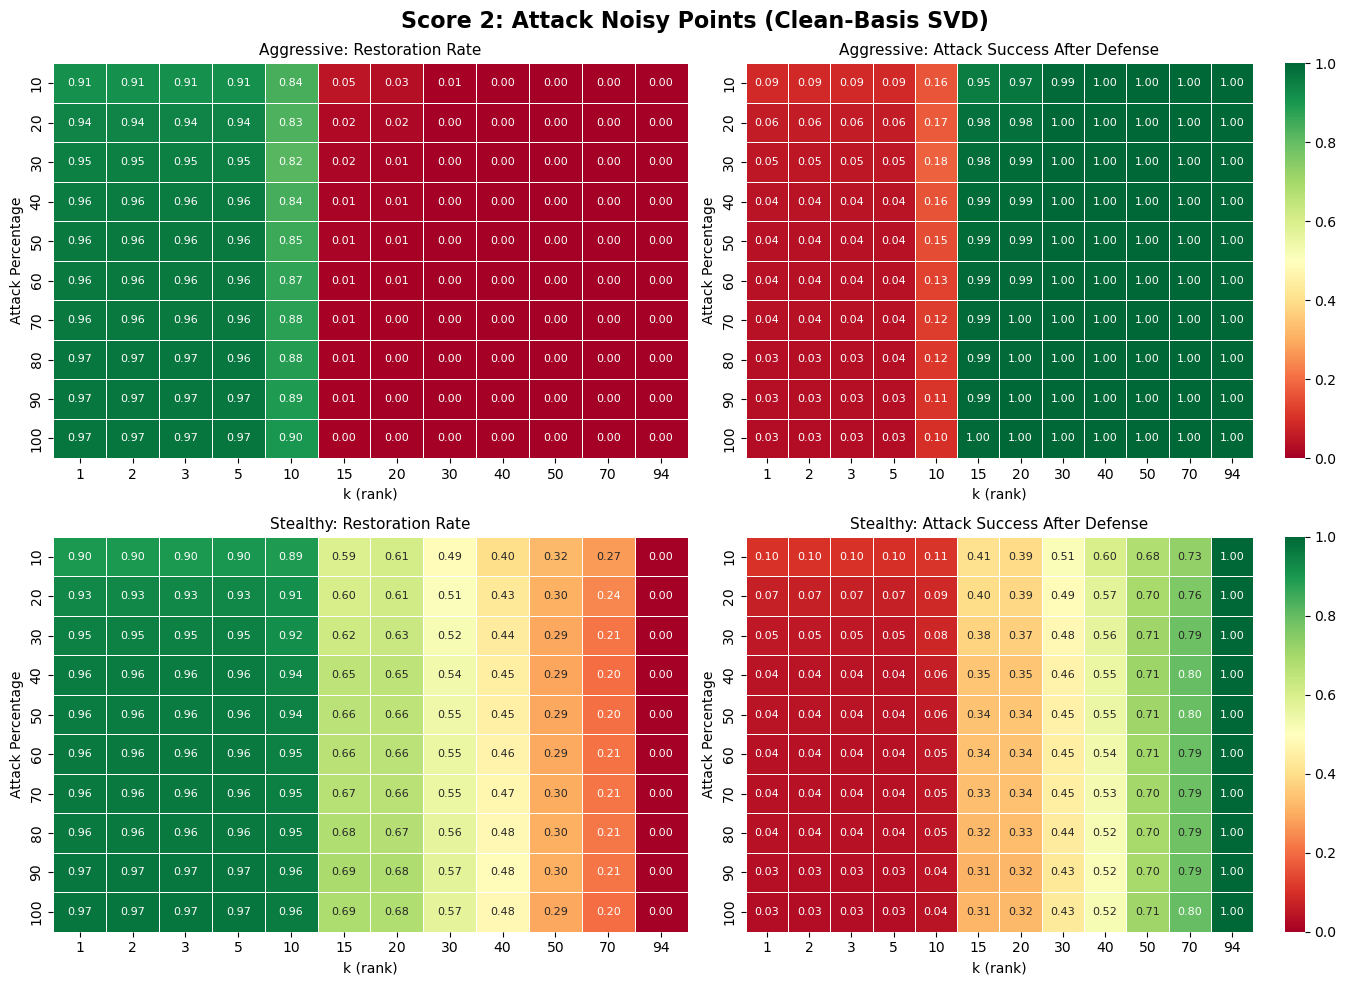

In [8]:
def plot_vaccination_heatmaps(df, score_name, tier_name, output_dir):
    sub = df[(df['score_type'] == score_name) & (df['tier'] == tier_name)]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f'{score_name}: Attack {tier_name.capitalize()} Points (Clean-Basis SVD)',
        fontsize=16, fontweight='bold',
    )

    panels = [
        (0, 0, 'aggressive', 'restoration_rate', 'Aggressive: Restoration Rate'),
        (0, 1, 'aggressive', 'asr_after',        'Aggressive: Attack Success After Defense'),
        (1, 0, 'stealthy',   'restoration_rate', 'Stealthy: Restoration Rate'),
        (1, 1, 'stealthy',   'asr_after',        'Stealthy: Attack Success After Defense'),
    ]

    for row, col, regime, metric, title in panels:
        ax = axes[row, col]
        regime_data = sub[sub['regime'] == regime]
        pivot = regime_data.pivot(index='attack_pct', columns='k', values=metric)
        pivot = pivot.sort_index(ascending=True)

        sns.heatmap(
            pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5,
            cbar=(col == 1),
            annot_kws={'size': 8},
        )
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('k (rank)')
        ax.set_ylabel('Attack Percentage')

    plt.tight_layout()
    fname = f'vaccination_clean_{score_name.lower().replace(" ", "")}_{tier_name}.png'
    fig.savefig(output_dir / fname, dpi=150, bbox_inches='tight')
    print(f'Saved {fname}')
    plt.show()


for score_name in score_orders:
    for tier_name in ['structural', 'noisy']:
        plot_vaccination_heatmaps(df, score_name, tier_name, OUTPUT_DIR)

## 6. Save Summary

In [9]:
summary = {
    'config': {
        'alpha': ALPHA, 'maxiters': MAXITERS,
        'lambdas': {k: float(v) for k, v in LAMBDAS.items()},
        'attack_pcts': ATTACK_PCTS, 'k_ranks': K_RANKS,
        'n_train_mlp': int(X_train.shape[0]),
        'n_svd_basis_rows': n_svd_basis_rows,
        'n_test': int(n_test), 'n_correct': int(n_correct),
        'svd_basis': "10% partition Vt_svd (clean_svd_basis.npz)",
        'data_dir': str(DATA_DIR),
        'adv_samples_from': str(PREV_RESULTS_DIR),
    },
    'attack_success': {
        regime: int(attack_success[regime][correct_indices].sum())
        for regime in LAMBDAS
    },
}
with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All results saved to', OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name:45s} ({p.stat().st_size/1024:.1f} KB)')

All results saved to ../../outputs/taiwan_bankruptcy_targeted_vaccination_clean_basis_10_40_50
  summary.json                                  (0.8 KB)
  vaccination_clean_score1_noisy.png            (338.3 KB)
  vaccination_clean_score1_structural.png       (313.1 KB)
  vaccination_clean_score2_noisy.png            (342.2 KB)
  vaccination_clean_score2_structural.png       (305.6 KB)
  vaccination_sweep.csv                         (68.9 KB)
